In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

# Food categories
foods = [
    "pizza", "burger", "dosa", "idli", "rice", "pasta", "salad",
    "sandwich", "fries", "noodles", "biryani", "paneer", "chicken",
    "egg", "fish", "cake", "icecream", "apple", "banana", "orange"
]

n = 100000  # 1 lakh entries

data = {
    "food": np.random.choice(foods, n),
    "calories": np.random.randint(50, 500, n),
    "carbs": np.random.randint(10, 100, n),
    "protein": np.random.randint(1, 50, n),
    "fat": np.random.randint(1, 50, n)
}

df = pd.DataFrame(data)

print("✅ Dataset created:", df.shape)
df.head()

✅ Dataset created: (100000, 5)


,food,calories,carbs,protein,fat
0,salad,151,89,35,13
1,orange,224,44,6,3
2,fish,389,58,49,15
3,biryani,97,63,32,5
4,sandwich,51,60,28,35


In [2]:
df.to_csv("food_dataset_1L.csv", index=False)

            calories          carbs        protein            fat
count  100000.000000  100000.000000  100000.000000  100000.000000
mean      274.186900      54.427810      24.960620      25.081720
std       129.764405      25.970674      14.162641      14.126266
min        50.000000      10.000000       1.000000       1.000000
25%       162.000000      32.000000      13.000000      13.000000
50%       274.000000      54.000000      25.000000      25.000000
75%       386.000000      77.000000      37.000000      37.000000
max       499.000000      99.000000      49.000000      49.000000


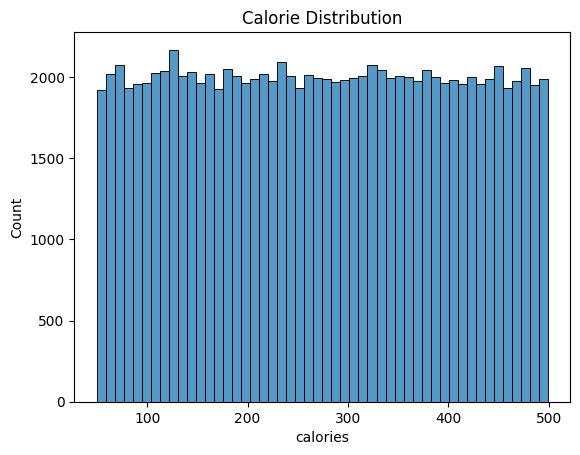

In [3]:
print(df.describe())

import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['calories'], bins=50)
plt.title("Calorie Distribution")
plt.show()

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['calories', 'carbs', 'protein', 'fat']])

kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(df.head())

       food  calories  carbs  protein  fat  cluster
0     salad       151     89       35   13        3
1    orange       224     44        6    3        1
2      fish       389     58       49   15        2
3   biryani        97     63       32    5        3
4  sandwich        51     60       28   35        3


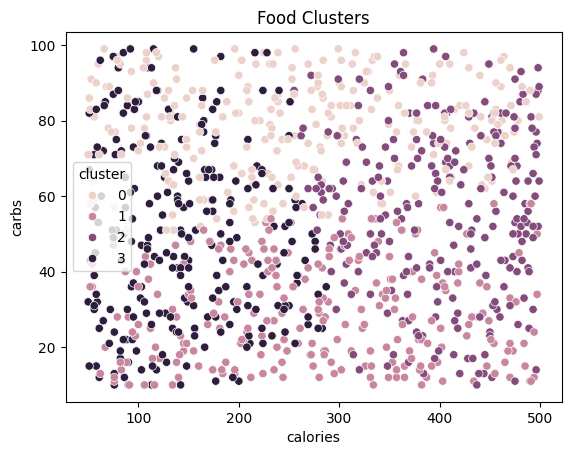

In [5]:
sns.scatterplot(data=df.sample(1000), x='calories', y='carbs', hue='cluster')
plt.title("Food Clusters")
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

X = df[['carbs', 'protein', 'fat']]
y = df['calories']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))

MAE: 112.71125355561658


In [7]:
def predict_calories(carbs, protein, fat):
    return model.predict([[carbs, protein, fat]])[0]

print("Estimated calories:", predict_calories(50, 10, 20))

Estimated calories: 273.4659233968908


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [8]:
food_calorie_map = df.groupby('food')['calories'].mean().to_dict()

print(food_calorie_map
)

{'apple': 276.69486038041276, 'banana': 275.28707943460086, 'biryani': 274.1691552464717, 'burger': 275.0007988815658, 'cake': 274.0817006269593, 'chicken': 272.7274844720497, 'dosa': 269.9135046919625, 'egg': 272.0037098103875, 'fish': 276.23554048663743, 'fries': 274.3651518158365, 'icecream': 274.67474185861795, 'idli': 276.67711847588805, 'noodles': 272.3541708142544, 'orange': 273.1838412189254, 'paneer': 270.600039737731, 'pasta': 276.8070842505503, 'pizza': 274.01771693174953, 'rice': 273.0203758654797, 'salad': 275.3768551945447, 'sandwich': 276.50626009693053}


In [12]:
food_summary = df.groupby('food').agg({
    'calories': 'mean',
    'carbs': 'mean',
    'protein': 'mean',
    'fat': 'mean',
    'cluster': lambda x: x.mode()[0]
}).reset_index()

food_summary = food_summary.round(2)

print("✅ Food summary created")
food_summary.head()

✅ Food summary created


,food,calories,carbs,protein,fat,cluster
0,apple,276.69,54.42,24.99,24.94,3
1,banana,275.29,54.29,24.97,25.08,2
2,biryani,274.17,54.78,24.78,25.25,0
3,burger,275.00,54.70,25.15,25.13,0
4,cake,274.08,54.05,25.35,25.40,3


In [13]:
def get_food_summary(food_name):
    food_name = food_name.lower()

    result = food_summary[food_summary['food'] == food_name]

    if result.empty:
        print("❌ Food not found in dataset")
        return

    row = result.iloc[0]

    print("\n🍽️ FOOD ANALYSIS REPORT")
    print("="*35)
    print(f"Food Item   : {row['food'].title()}")
    print(f"Calories    : {row['calories']} kcal")
    print(f"Carbs       : {row['carbs']} g")
    print(f"Protein     : {row['protein']} g")
    print(f"Fat         : {row['fat']} g")

    # Cluster meaning
    cluster_type = {
        0: "Low Calorie (Diet Friendly)",
        1: "Medium Calorie",
        2: "High Calorie (Energy Dense)",
        3: "Very High Calorie"
    }

    print(f"Category    : {cluster_type.get(row['cluster'], 'Unknown')}")

    # Health suggestion
    if row['calories'] < 150:
        print("Suggestion  : Good for weight loss 👍")
    elif row['calories'] < 300:
        print("Suggestion  : Moderate consumption ⚖️")
    else:
        print("Suggestion  : Limit intake ⚠️")

In [14]:
get_food_summary("pizza")


🍽️ FOOD ANALYSIS REPORT
Food Item   : Pizza
Calories    : 274.02 kcal
Carbs       : 54.44 g
Protein     : 24.93 g
Fat         : 25.18 g
Category    : Medium Calorie
Suggestion  : Moderate consumption ⚖️


In [15]:
food_input = input("Enter food name: ")
get_food_summary(food_input)

Enter food name: Icecream

🍽️ FOOD ANALYSIS REPORT
Food Item   : Icecream
Calories    : 274.67 kcal
Carbs       : 54.08 g
Protein     : 25.17 g
Fat         : 25.18 g
Category    : Very High Calorie
Suggestion  : Moderate consumption ⚖️
